In [1]:
from qiskit import *
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_bloch_multivector
%matplotlib inline

In [2]:
def run_on_simulators(circuit):
    statevector_job = AerSimulator(method="statevector")

    statevector_circuit = circuit.copy()
    statevector_circuit.save_statevector()

    result = statevector_job.run(statevector_circuit).result()
    statevector = result.get_statevector()

    num_qubits = circuit.num_qubits

    qasm_circuit = circuit.copy()
    qasm_circuit.measure(
        [i for i in range(num_qubits)],
        [i for i in range(num_qubits)]
    )

    qasm_job = AerSimulator()
    result = qasm_job.run(qasm_circuit, shots=1024).result()
    counts = result.get_counts()

    return statevector, counts

In [3]:
circuit = QuantumCircuit(2, 2)
statevector, counts = run_on_simulators(circuit)

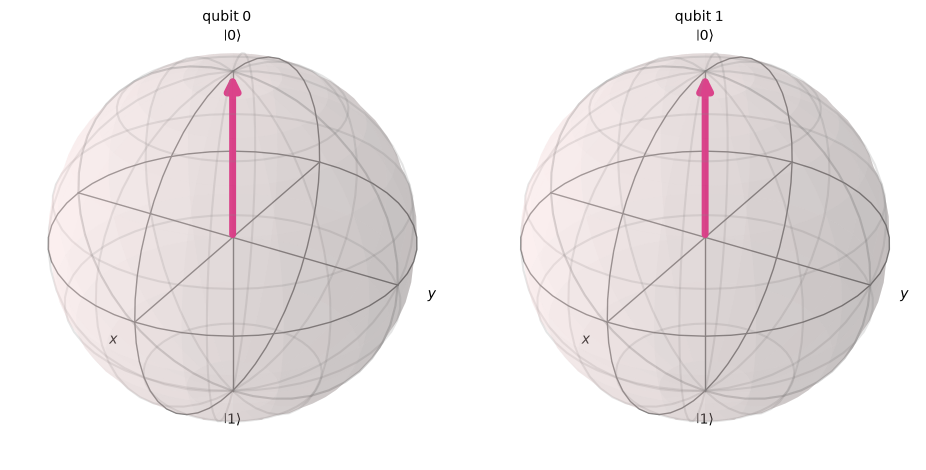

In [4]:
plot_bloch_multivector(statevector);

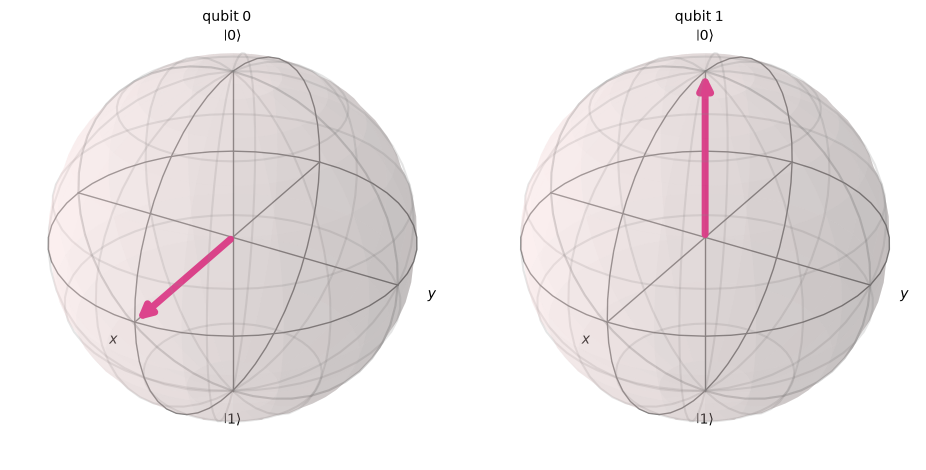

In [5]:
circuit.h(0)
statevector, counts = run_on_simulators(circuit)
plot_bloch_multivector(statevector);

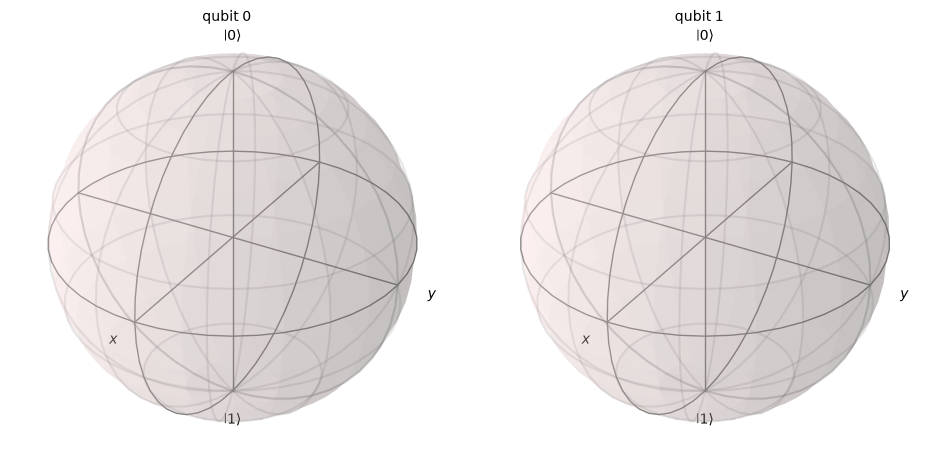

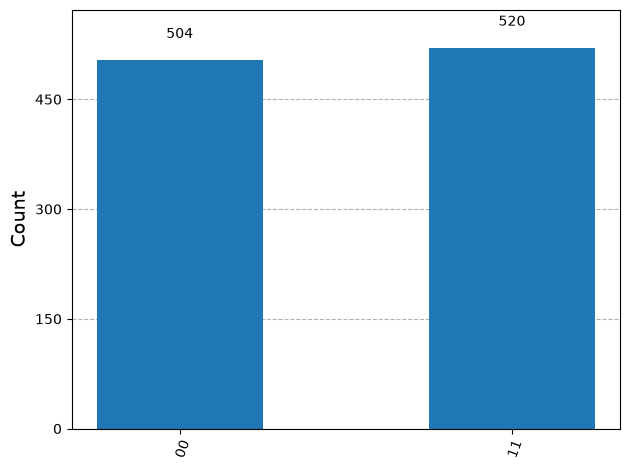

In [6]:
circuit = QuantumCircuit(2, 2)
circuit.h(0)
circuit.cx(0, 1)
statevector, counts = run_on_simulators(circuit)
plot_bloch_multivector(statevector)
plot_histogram(counts);

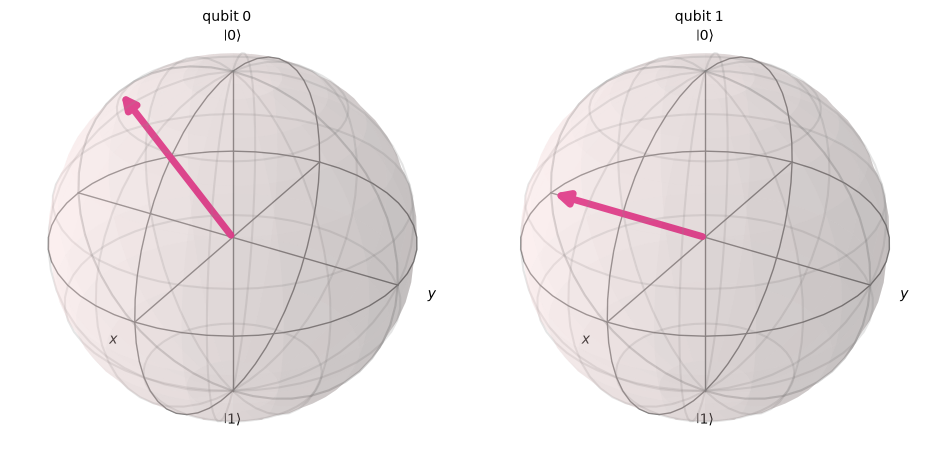

In [24]:
import math

circuit = QuantumCircuit(2, 2)
circuit.rx(math.pi/4, 0)
circuit.rx(math.pi/2, 1)
statevector, counts = run_on_simulators(circuit)
plot_bloch_multivector(statevector);

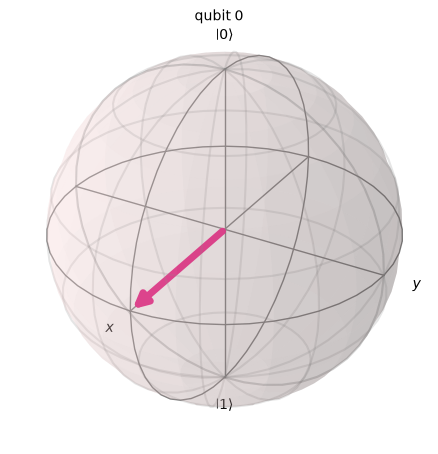

In [25]:
circuit = QuantumCircuit(1, 1)
circuit.h(0)
statevector, counts = run_on_simulators(circuit)
plot_bloch_multivector(statevector);

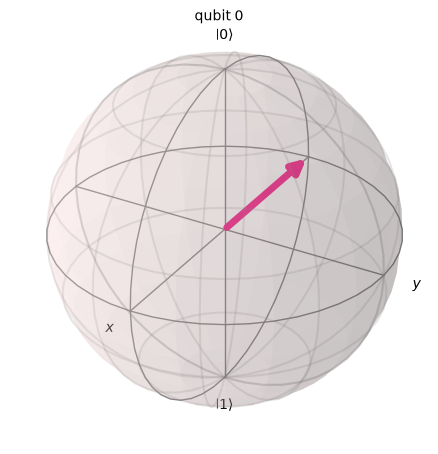

In [26]:
circuit = QuantumCircuit(1, 1)
circuit.h(0)
circuit.z(0)
statevector, counts = run_on_simulators(circuit)
plot_bloch_multivector(statevector);